# Task 1: Download and Visualize Sentinel 2 Data

In this task we focus on the municipality of **São Félix do Xingu** in the eastern sector of the Pará state in Brazil. The goal is to retrieve two Sentinel 2 tiles from the Copernicus AWS archive for two dates separated by a period of reported forest loss. Afterwards, you will visualize and qualitatively analyze these tiles.

## 1.0 Optional Step: Global Forest Watch Data Review

Before working with spectral data we can consult Global Forest Watch for annual forest cover change statistics in São Félix do Xingu.
Please look at the [Global Forest Watch map for São Félix do Xingu, Brazil](https://gfw.global/3H8Uut5) and evaluate the forst loss in the region.


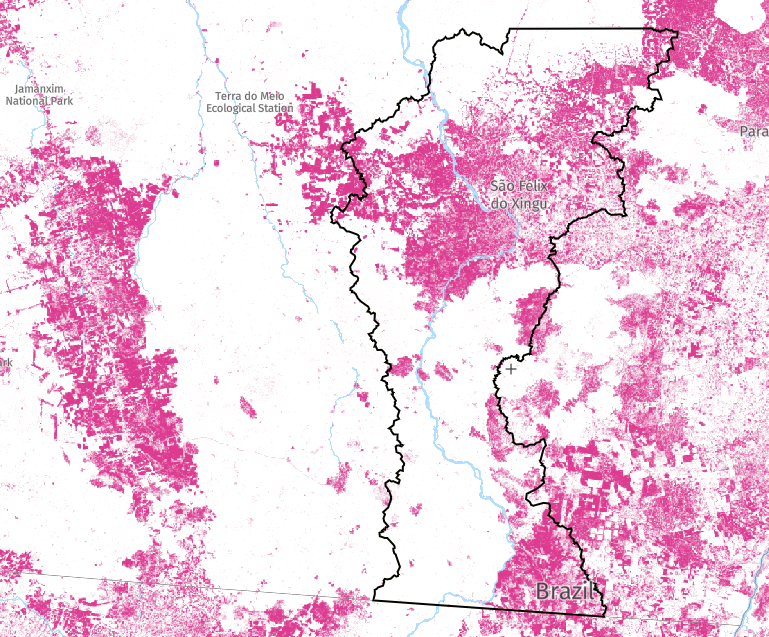


According to [Global Forest Watch](https://gfw.global/3FKpuzl), São Félix do Xingu experienced a loss of 2.15 million hectares of tree cover between 2001 and 2024, which is about a 27 percent decrease. In the more recent period from 2018 to 2024 the municipality lost 794 thousand hectares of tree cover equivalent to a 10 percent decrease in tree cover and 345 million tonnes of carbon dioxide equivalent emissions. 
To align our satellite imagery analysis with both the magnitude of recent forest loss and the availability of high quality Sentinel 2 acquisitions we focus on the years 2018 and 2024. 

###  Contextual and Seasonal Considerations

To interpret these forest-cover statistics we must consider the principal land-use drivers in São Félix do Xingu; cattle ranching expansion and commercial agriculture have accelerated canopy removal in recent years, and infrastructure development such as logging roads fragment contiguous forest blocks.

Furthermore we must account for seasonal and atmospheric factors when selecting our two dates; the dry season in this region, roughly July through September, offers the clearest skies for optical imagery whereas the wet season introduces increased cloud cover and potential [sun-glint](https://www.euspaceimaging.com/blog/2023/12/18/how-eusi-avoids-sun-glint-in-satellite-images/) off wet leaves. 

## 1.1 Accessing Earth Observation Data via Copernicus Data Space S3

To download Sentinel-2 products from Copernicus Data Space via S3 you must first register for the Data Space service by creating a Copernicus user account. Once authenticated you can generate S3 credentials comprising an access key ID and a secret access key (see [Copernicus Data Space S3 API documentation](https://documentation.dataspace.copernicus.eu/APIs/S3.html)). Store these credentials securely in a `.env` file at the project root so that they can be loaded at runtime without exposing sensitive information.

### Detailed Task description
1. Register and obtain S3 credentials from Copernicus Data Space, store your access key ID and secret access key in a `.env` file.
   (Note: Please do not upload this file for the submission. We will use our own .env file)


### Imports
These are all imports we used when solving the task. Please leave them as is even though you might not need all of them.

In [3]:
import os
import rootutils
root = rootutils.setup_root(os.path.abspath(''), dotenv=True, pythonpath=True, cwd=False)

data_path = root / "data"
data_path.mkdir(exist_ok=True)
output_dir = root / "output"
output_dir.mkdir(exist_ok=True)


In [4]:
from datetime import date, datetime
from pathlib import Path
from typing import Optional, Iterable, Tuple

import boto3
import numpy as np
import osmnx as ox
import pandas as pd
import requests
from dotenv import load_dotenv
from collections import defaultdict
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon


pd.set_option('display.max_columns', None)  
pd.set_option('display.max_colwidth', None) 

DESIRED_BANDS =['B02_10m', 'B03_10m', 'B04_10m', 'B08_10m',
               'B05_20m', 'B06_20m', 'B07_20m', 'B8A_20m',
               'B11_20m', 'B12_20m']

load_dotenv()  # defaults to loading .env from current dir

access_key = os.getenv("AWS_ACCESS_KEY_ID")
secret_key = os.getenv("AWS_SECRET_ACCESS_KEY")

In [ ]:
# Additionally, I import util functions that where mostly copied from the lab notebooks
# I use them in all tasks so I moved them to an external python file. I hope this is okay.
import labUtils as labUtils

## 1.2 Querying the Copernicus OData API for Sentinel-2 Data

In this step, you will identify and retrieve Sentinel-2 Level 2A (L2A) imagery for São Félix do Xingu for two specific dry season periods. The goal is to obtain comparable data from both 2018 and 2024 for subsequent analysis.

**Note:** Sentinel-2 L2A products are atmospherically corrected surface reflectance data, processed from Level 1C using the Sen2Cor processor. For detailed information on these products, refer to the [Sentinel-2 L2A documentation](https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a).

### Detailed Task description

1. Query the Copernicus OData API to retrieve Sentinel-2 Level 2A products satisfying the following constraints for both 2018 and 2024:

- **Area of interest:** Full envelope of São Félix do Xingu
- **Acquisition dates:** Between 20 July and 30 July  
- **Cloud cover:** Maximum of 0.5%  
- **Product type:** Level 2A (atmospherically corrected products)  
- **Spatial consistency:** Retain only those Sentinel-2 tiles that are present in both years (based on tile name)
- **Most recent tile:** ...

   You can use the function `dataspace_dataframe_from_attributes` to obtain the dataframe (see Lab01).

2. Convert both resulting DataFrames into GeoDataFrames using the available spatial metadata. Visualize them with the `explore()` method to verify whether the selected tiles overlap spatially.


In [ ]:
# Get The ROI envelope
sao_felix_gdf = ox.geocode_to_gdf("São Félix do Xingu")
sao_felix_envelope_gdf = sao_felix_gdf.envelope

# Prepare all other attributes
aoi = sao_felix_envelope_gdf.to_wkt()
satellite = "SENTINEL-2"
cloud_lims = [0, 0.5]
product_type = "S2MSI2A"

# -----------------------

# Dataframe Utils functions
def has_product_type(attributes_list):
    for attr in attributes_list:
        if (
            attr.get("Name") == "productType"
            and attr.get("Value") == product_type
        ):
            return True
    return False

def get_tileId(attributes_list):
    for attr in attributes_list:
        if attr.get("Name") == "tileId":
            return attr.get("Value")
    return None

# --------------------

def get_products_by_year(year):
    start_date = date(year=year, month=7, day=20)
    end_date = date(year=year, month=7, day=30)

    products = labUtils.dataspace_dataframe_from_attributes(
        collection=satellite,
        aoi=str(aoi[0]),
        start_date=start_date.strftime("%Y-%m-%d"),
        end_date=end_date.strftime("%Y-%m-%d"),
        attributes=[
            # Note:
            # Tried filtering for product type here but got a weird error from copernicus api
            # my request tring was:  and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'ProductType' and att/OData.CSC.StringAttribute/Value eq 'S2MSI1C')
            # and the API returned: Invalid field: ProductType
            # so now i am post-filtering the results a few lines after this
            #('ProductType', 'eq', product_type),
            ('cloudCover', 'le', cloud_lims[1]),
            ('cloudCover', 'ge', cloud_lims[0])
        ],
        max_returned_items=1000,
    )

    # filter for product type
    products = products[products['Attributes'].apply(has_product_type)]

    # add tileId directly as a DF column for better easier later on
    products["tileId"] = products["Attributes"].apply(get_tileId)
    
    return products

products_2018 = get_products_by_year(2018)
products_2024 = get_products_by_year(2024)

# make sure only tiles tha appear in both years are visible
common_tiles = list(set(products_2018["tileId"].tolist()) & set(products_2024["tileId"].tolist()))
products_2018 = products_2018[products_2018['tileId'].isin(common_tiles)]
products_2024 = products_2024[products_2024['tileId'].isin(common_tiles)]

print(len(products_2018))
print(len(products_2024))

60
50


In [9]:
gdf_products_2018 = labUtils.copernicus_df_to_gdf(products_2018)
gdf_products_2024 = labUtils.copernicus_df_to_gdf(products_2024)

# Show the product areas over the defined region envelope
# I just show the first 15 tiles here for better readability
m = sao_felix_gdf.explore(color="red")
gdf_products_2018.head(15).explore(color="green", m=m)
gdf_products_2024.head(15).explore(color="blue", m=m)
sao_felix_envelope_gdf.explore(color="red", fill=False, m=m)

Ignored date conversions: ['EvictionDate', 'ContentDate']
Successful date conversions: ['OriginDate', 'PublicationDate', 'ModificationDate', 'endingDateTime', 'processingDate', 'beginningDateTime']
Ignored date conversions: ['EvictionDate', 'ContentDate', 'sourceProductOriginDate']
Successful date conversions: ['OriginDate', 'PublicationDate', 'ModificationDate', 'endingDateTime', 'processingDate', 'beginningDateTime']


**Result Description**:

I managed to get the results as desired from the copernicus API.

I didn't manage to filter the productType directly through the request URL so I had to do that in post filter methods.

The map in the previous cell shows the requested Area, the envelop around it and a small sample of the collected product areas.

## 1.3 Downloading and Visualizing Sentinel-2 Tile T22MCU

Based on the results of the previous step, we now narrow our analysis to a single tile. According to Global Forest Watch and our tile inspection using the GeoDataFrame, tile **T22MCU** lies in the northern sector of São Félix do Xingu, an area that has experienced significant deforestation between 2018 and 2024. The tile shows complete data coverage and spatially aligns with settlement and agricultural zones, making it a suitable candidate for further analysis.

The goal in this step is to programmatically download selected bands from the Sentinel-2 Level 2A products for tile T22MCU for both 2018 and 2024 and to visualize the corresponding RGB composites. 

To minimize storage overhead, restrict the download to bands that are required for classification tasks compatible with the [BigEarthNet v2](https://arxiv.org/abs/1902.06148) label set. You can use the AWS S3 API (via `boto3`) for efficient access. Refer to the same [Copernicus Data Space S3 API documentation](https://documentation.dataspace.copernicus.eu/APIs/S3.html) for endpoint configuration and signing instructions.

### Detailed Task Description

1. **Tile Selection**  
   From the GeoDataFrame constructed in Task 1.2, filter the entries to retain only those with `tileName == 'T22MCU'`. Confirm that exactly one product is retained for each of the two target years (2018 and 2024).

2. **Band Selection and Download via `boto3`**  
   Use the AWS SDK for Python (`boto3`) to authenticate with the Copernicus Data Space S3 endpoint using credentials stored in the `.env` file.  
   For each of the two selected products:
   - Access the product path from the S3 URL in the dataframe.
   - Retrieve only the following bands, organizing them into subfolders, respectively:

     ```
     DESIRED_BANDS = [
         'B02_10m', 'B03_10m', 'B04_10m', 'B08_10m',
         'B05_20m', 'B06_20m', 'B07_20m', 'B8A_20m',
         'B11_20m', 'B12_20m'
     ]
     ```

3. **RGB Composite Visualization**  
   For each year:
   - Stack bands `B04_10m` (red), `B03_10m` (green), and `B02_10m` (blue) (in this order!) into a 3-channel array.
   - Normalize the image, e.g. Quantile Based Normalization, and plot it.

4. **Interpretation**  
   Briefly describe in 2-3 paragraphs the visual differences between the two images. Comment on land cover, visible clearings, vegetation patterns, any atmospheric artifacts such as haze or clouds, and whatever else you notice.




In [11]:
DESIRED_BANDS = [
    'B02_10m', 'B03_10m', 'B04_10m', 'B08_10m',
    'B05_20m', 'B06_20m', 'B07_20m', 'B8A_20m',
    'B11_20m', 'B12_20m'
]

# -----------------
# Tile Selection

requested_tileId = "22MCU" 

def is_tiledID(attributes_list):
    for attr in attributes_list:
        if (
            attr.get("Name") == "tileId"
            and attr.get("Value") == requested_tileId
        ):
            return True
    return False

tile_products_2018 = products_2018[products_2018['Attributes'].apply(is_tiledID)]
tile_products_2024 = products_2024[products_2024['Attributes'].apply(is_tiledID)]

assert len(tile_products_2018) == 1 and len(tile_products_2024) == 1

#print("S3 Paths:")
#print(tile_products_2018["S3Path"])
#print(tile_products_2024["S3Path"])


# ---------------
# Setting up boto3
# guided by: https://documentation.dataspace.copernicus.eu/APIs/S3.html
session = boto3.session.Session()

s3 = boto3.resource(
    's3',
    endpoint_url='https://eodata.dataspace.copernicus.eu',
    aws_access_key_id=access_key,
    aws_secret_access_key=secret_key,
    region_name='default'
)

def is_file_in_desired_bands(filekey):
    for band in DESIRED_BANDS:
        if band.lower() in filekey.lower():
            return True
    return False

def download(bucket, product: str, target: str = "") -> None:
    """
    Downloads every file in bucket with provided product as prefix

    Raises FileNotFoundError if the product was not found

    Args:
        bucket: boto3 Resource bucket object
        product: Path to product
        target: Local catalog for downloaded files. Should end with an `/`. Default current directory.
    """
    files = bucket.objects.filter(Prefix=product)
    if not list(files):
        raise FileNotFoundError(f"Could not find any files for {product}")
    for file in files:
        target_path = os.path.join(target, file.key)
        if is_file_in_desired_bands(file.key): # Requirement of task: Only download reuired band files to save storage
            os.makedirs(os.path.dirname(target_path), exist_ok=True)
            if not os.path.exists(target_path):
                bucket.download_file(file.key, target_path)
                print(f"Downloaded: {file}")
            else:
                print(f"file already local, not downloading: {file.key}")
        

# -------------------
# Actually downloading the files

def download_desired_bands(product_df_row, year):
    product_full_path = product_df_row["S3Path"]
    boto_path = product_full_path.lstrip("/").replace("eodata/", "", 1)
    download(s3.Bucket("eodata"), boto_path, data_path / f"{year}")

download_desired_bands(tile_products_2018.iloc[0], 2018)
download_desired_bands(tile_products_2024.iloc[0], 2024)

Downloaded: s3.ObjectSummary(bucket_name='eodata', key='Sentinel-2/MSI/L2A_N0500/2018/07/23/S2B_MSIL2A_20180723T135109_N0500_R024_T22MCU_20230628T084231.SAFE/GRANULE/L2A_T22MCU_A007200_20180723T135109/IMG_DATA/R10m/T22MCU_20180723T135109_B02_10m.jp2')
Downloaded: s3.ObjectSummary(bucket_name='eodata', key='Sentinel-2/MSI/L2A_N0500/2018/07/23/S2B_MSIL2A_20180723T135109_N0500_R024_T22MCU_20230628T084231.SAFE/GRANULE/L2A_T22MCU_A007200_20180723T135109/IMG_DATA/R10m/T22MCU_20180723T135109_B03_10m.jp2')
Downloaded: s3.ObjectSummary(bucket_name='eodata', key='Sentinel-2/MSI/L2A_N0500/2018/07/23/S2B_MSIL2A_20180723T135109_N0500_R024_T22MCU_20230628T084231.SAFE/GRANULE/L2A_T22MCU_A007200_20180723T135109/IMG_DATA/R10m/T22MCU_20180723T135109_B04_10m.jp2')
Downloaded: s3.ObjectSummary(bucket_name='eodata', key='Sentinel-2/MSI/L2A_N0500/2018/07/23/S2B_MSIL2A_20180723T135109_N0500_R024_T22MCU_20230628T084231.SAFE/GRANULE/L2A_T22MCU_A007200_20180723T135109/IMG_DATA/R10m/T22MCU_20180723T135109_B08_10

10 images found in C:\dev\TU\IPEO\ipl4eo_miniproject_2025\data\2018
10 images found in C:\dev\TU\IPEO\ipl4eo_miniproject_2025\data\2024


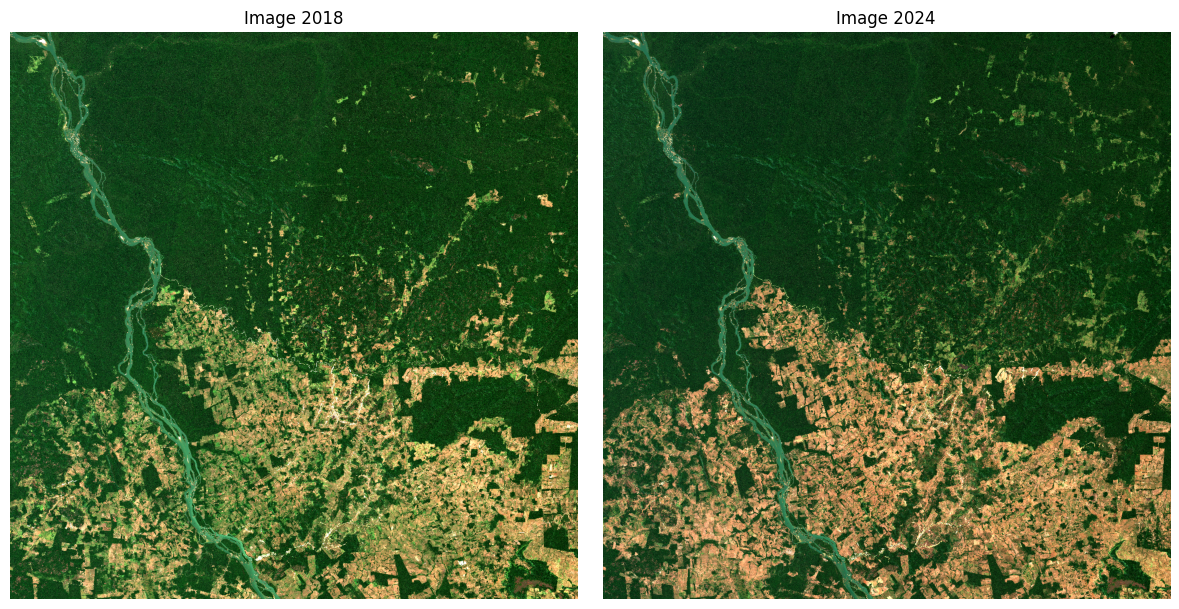

In [12]:
def plot_images(img1, img2, titles=("Image 2018", "Image 2024"), figsize=(12, 6)):
    fig, axs = plt.subplots(1, 2, figsize=figsize)

    axs[0].imshow(img1)
    axs[0].set_title(titles[0])
    axs[0].axis("off")

    axs[1].imshow(img2)
    axs[1].set_title(titles[1])
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

# This is a downsample function I use when visualizing the images. Otherwise, the image is too big and my laptop crashes
def downsample_array(data, scale=10):
    return data[::scale, ::scale, :]


# ------------
# Visualizing the two tile images

def get_downsampled_rgb_from_folder(folderPath):
    tile_reader = labUtils.S2TileReader(folderPath)
    combined_bands = np.stack(
        [tile_reader.read_band(b) for b in ("B04_10m", "B03_10m", "B02_10m")],
        axis=-1,
    )
    downsampled_image = downsample_array(combined_bands)
    downsampled_image = labUtils.quant_norm_data(downsampled_image)
    return downsampled_image


img_2018 = get_downsampled_rgb_from_folder(Path(data_path / "2018"))
img_2024 = get_downsampled_rgb_from_folder(Path(data_path / "2024"))

plot_images(img_2018, img_2024)

**Result Description**:

The first thing I realised was how big the image files where (array shape: 10980, 10980, 3). This caused the quant_normalization function from the lab01 to use a lot of memory and sometimes even crash my pc. To fix that, I added a small downscale method that can be used for visualization. Please note that for the later ML tasks I will of course not use this downscale function to not loose data.

When visually comparing the two Images, I am positively surprised that the clouds filters worked perfectley and there seems to be almost zero cloud coverage, fog, or anything similar. It is visible that in 2024 the de-forested areas got a lot more dense and intense compared to 2018. Just from my eye sight it looks like the area itself  has not expanded too far though, but a lot of green spots inside the de-forested area dissapeared.